# Example-21: Subset of coupled twiss parameters from amplitudes and phases

In [1]:
# Horizontal and vertical coordinates (linear coupled case) are given by

# qx(n)  = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n)  = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

# where frequencies (nux, nuy), amplitudes (axx, axy, ayx, ayy) and phases (fxx, fxy, fyx, fyy)
# These parameters can be computed from harmonic decomposition of TbT signals (qx(n), qy(n))
# Horizontal and vertical normalized coordinates are given by

# Qx(n) = sqrt(2 ix) cos(2 pi nux n + fx)
# Qy(n) = sqrt(2 iy) cos(2 pi nuy n + fy)

# where invariants (or actions) (ix, iy) and phases/angles (fx, fy) set initial condition
# and are related to initial normalized coordinates as follows

# ix = 1/2*(Qx^2 + Px^2)
# iy = 1/2*(Qy^2 + Py^2)
# fx = -torch.atan2(Qx, Px)
# fy = -torch.atan2(Qy, Py)

# Initial phases (fx, fy) are equal to measured phases (fxx, fyy) if there are no calibration errors
# Normalized coordinates (Qx, Px, Qy, Py) are connected with laboratory frame coordinates (qx, px, qy, py) by normalization matrix
# Using initial values (ix, fx, iy, fy) and normalization matrix elements, amlitudes can be written as follows

# axx**2 = 2 * ix * n11**2
# axy**2 = 2 * iy * (n13**2 + n14**2)
# ayx**2 = 2 * ix * (n31**2 + n32**2)
# ayy**2 = 2 * iy * n33**2

# Similar, for phases, the correspondind expressions are given by

# fxx = fx
# fxy = torch.atan2((fy.sin() * n13 + fy.cos() * n14), (fy.cos() * n13 - fy.sin() * n14))
# fyx = torch.atan2((fx.sin() * n31 + fx.cos() * n32), (fx.cos() * n31 - fx.sin() * n32))
# fyy = fy

# Given the invariants (ix, iy), elements n11 and n33 can be obtained from amplitudes
# Elements n11 and n33 are positive and are related to normal (in-plane) beta functions

# bx = bxx = n11**2
# by = byy = n33**2

# Off-plane beta functions can be computed from coupled amplitudes

# bxy = (n13**2 + n14**2)
# byx = (n31**2 + n32**2)

# Using expressions for amplitudes and phase, it is possible to directly compute n13, n14, n31 and n32 elements

# n13 = axy/ayy*(fxy - fyy).cos()*n33
# n14 = axy/ayy*(fxy - fyy).sin()*n33
# n31 = ayx/axx*(fyx - fxx).cos()*n11
# n32 = ayx/axx*(fyx - fxx).sin()*n11

# Overall, it is possible to compute n11, n33, n13, n14, n31 and n32
# Two more elements are required to fully characterize normalizatiom matrix
# Note, elements n12 and n34 are zero by definitions, thus, there are eight free parameters

# In this example subset of twiss parameters is estimated from TbT (no noise, long data)
# Invariants are estimated from fit
# Frequencies, amplitudes and phases are estimated from harmonic decompositon

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

## Model setup

In [4]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [5]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2*2**10

In [6]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

In [7]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [8]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [9]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [10]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [11]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [12]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

In [13]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

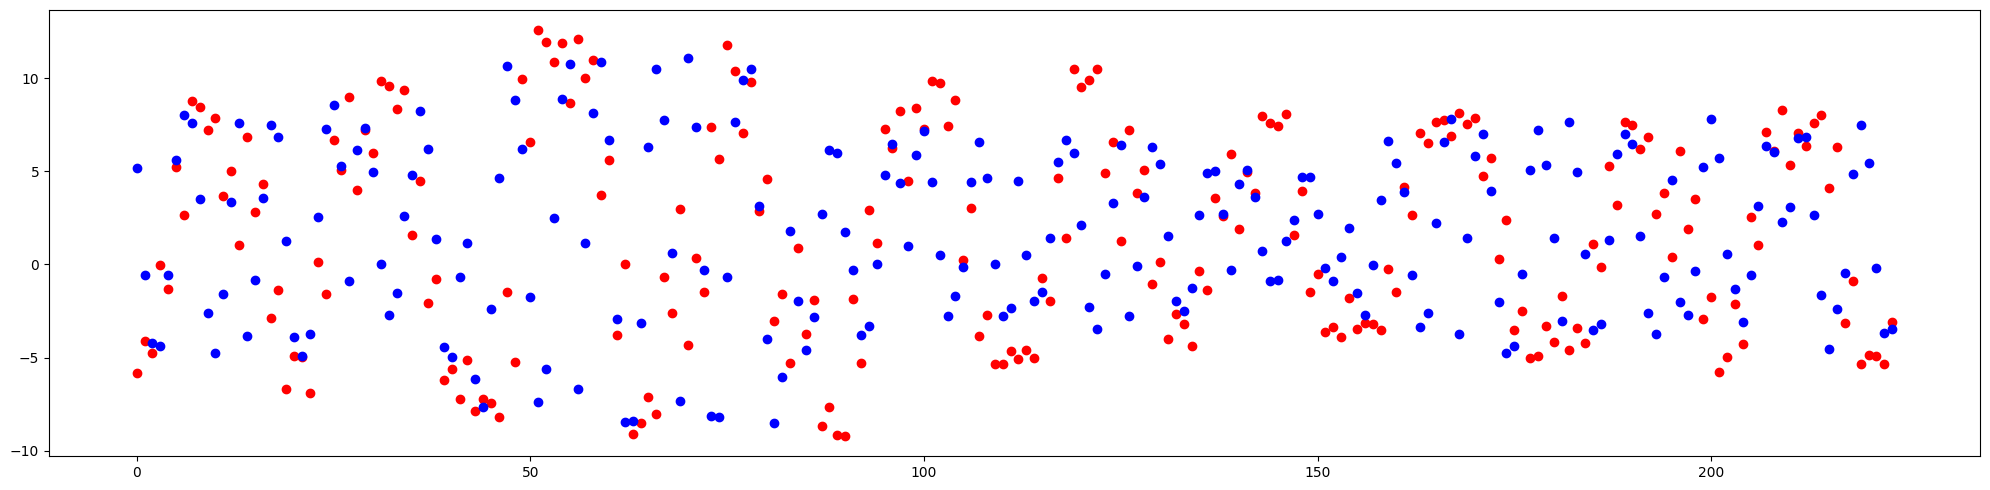

5.86
4.86


In [14]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [15]:
# Set twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

## Harmonic decomposition

In [16]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [17]:
# Compute exact invariants

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(ix.mean())
print(iy.mean())

tensor(1.2592e-08, dtype=torch.float64)
tensor(3.4896e-08, dtype=torch.float64)


In [18]:
# Perform harmonic decmposition of TbT data

In [19]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.reset()

In [20]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

In [21]:
# Compute amplitudes and phases (horizontal and vertical)

axx, sigma_axx, _ = d_x.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, sigma_fxx, _ = d_x.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, sigma_ayy, _ = d_y.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, sigma_fyy, _ = d_y.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [22]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx, axx.reshape(-1, 1)*(2*torch.pi*nux*t + fxx.reshape(-1, 1)).cos() + axy.reshape(-1, 1)*(2*torch.pi*nuy*t + fxy.reshape(-1, 1)).cos()))
print(torch.allclose(qy, ayy.reshape(-1, 1)*(2*torch.pi*nuy*t + fyy.reshape(-1, 1)).cos() + ayx.reshape(-1, 1)*(2*torch.pi*nux*t + fyx.reshape(-1, 1)).cos()))

True
True


In [23]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              sigma_nux, sigma_nuy,
              sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

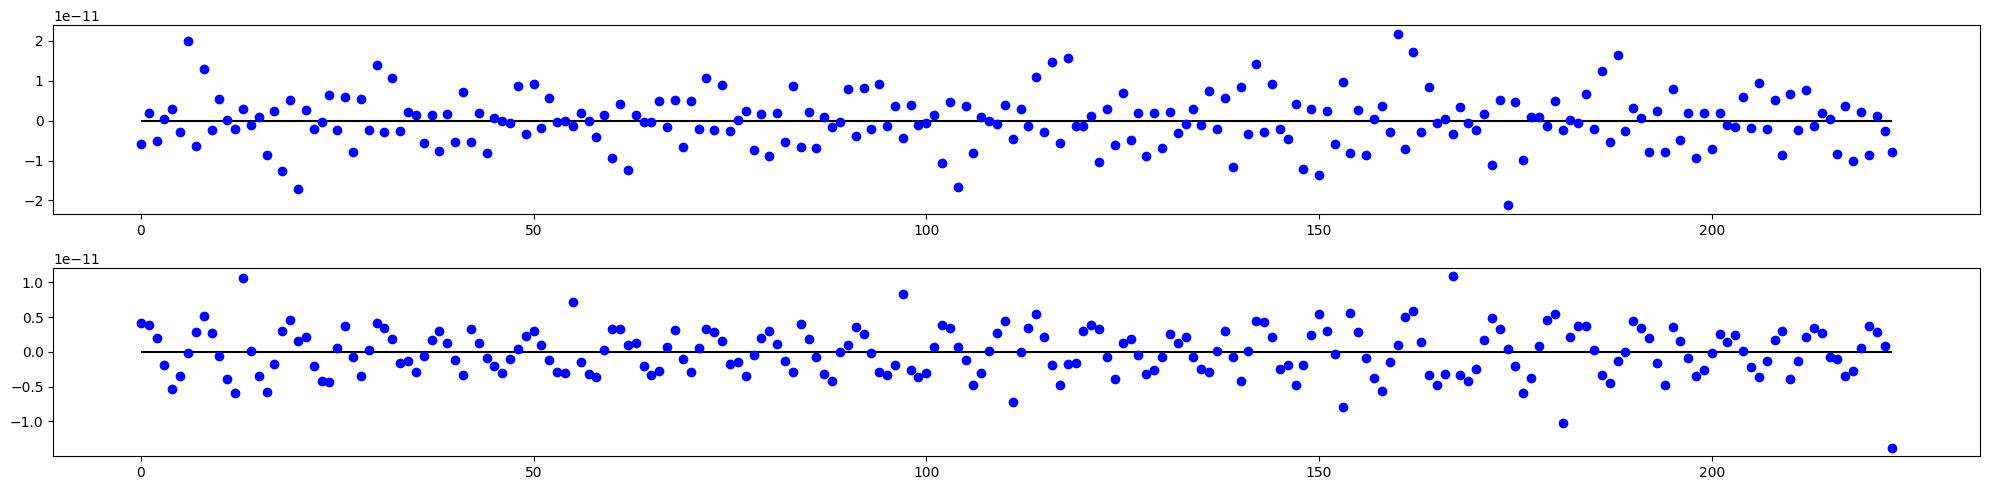

In [24]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

In [25]:
# Set twiss

twiss = Twiss(model, table, limit=4)

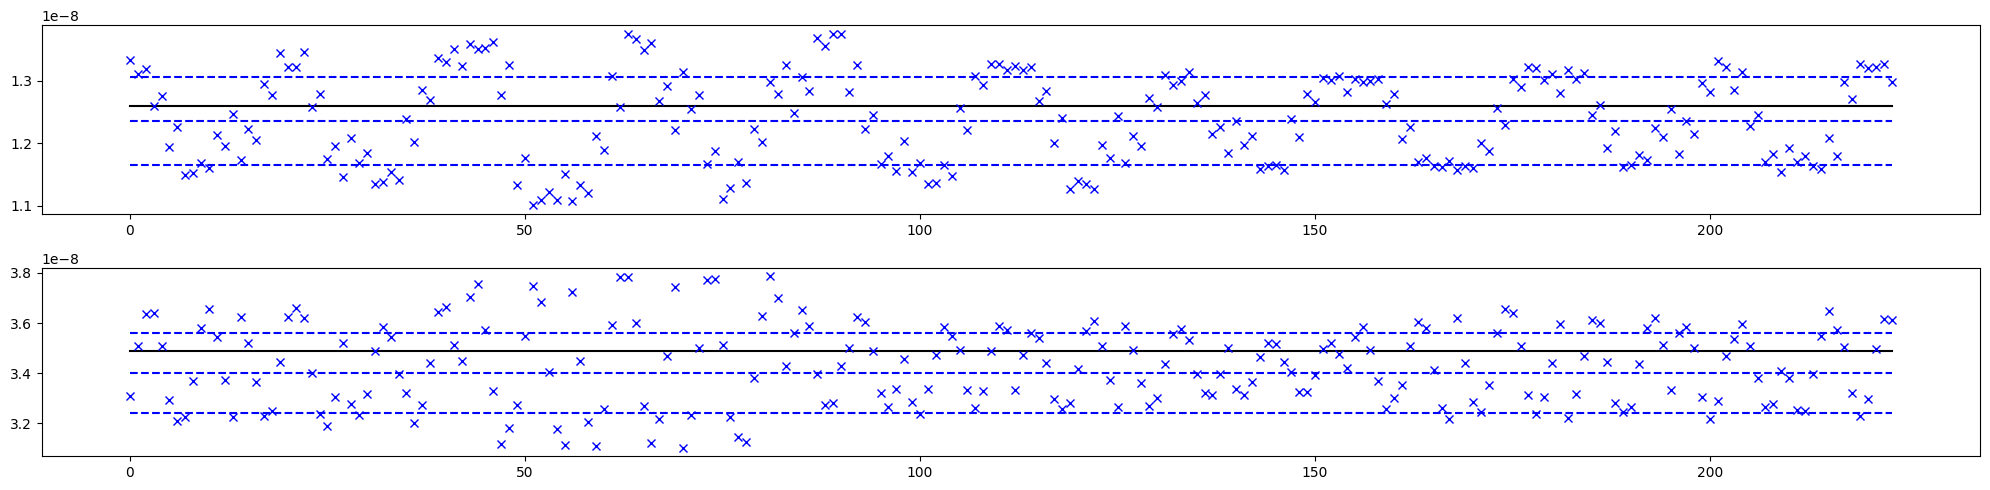

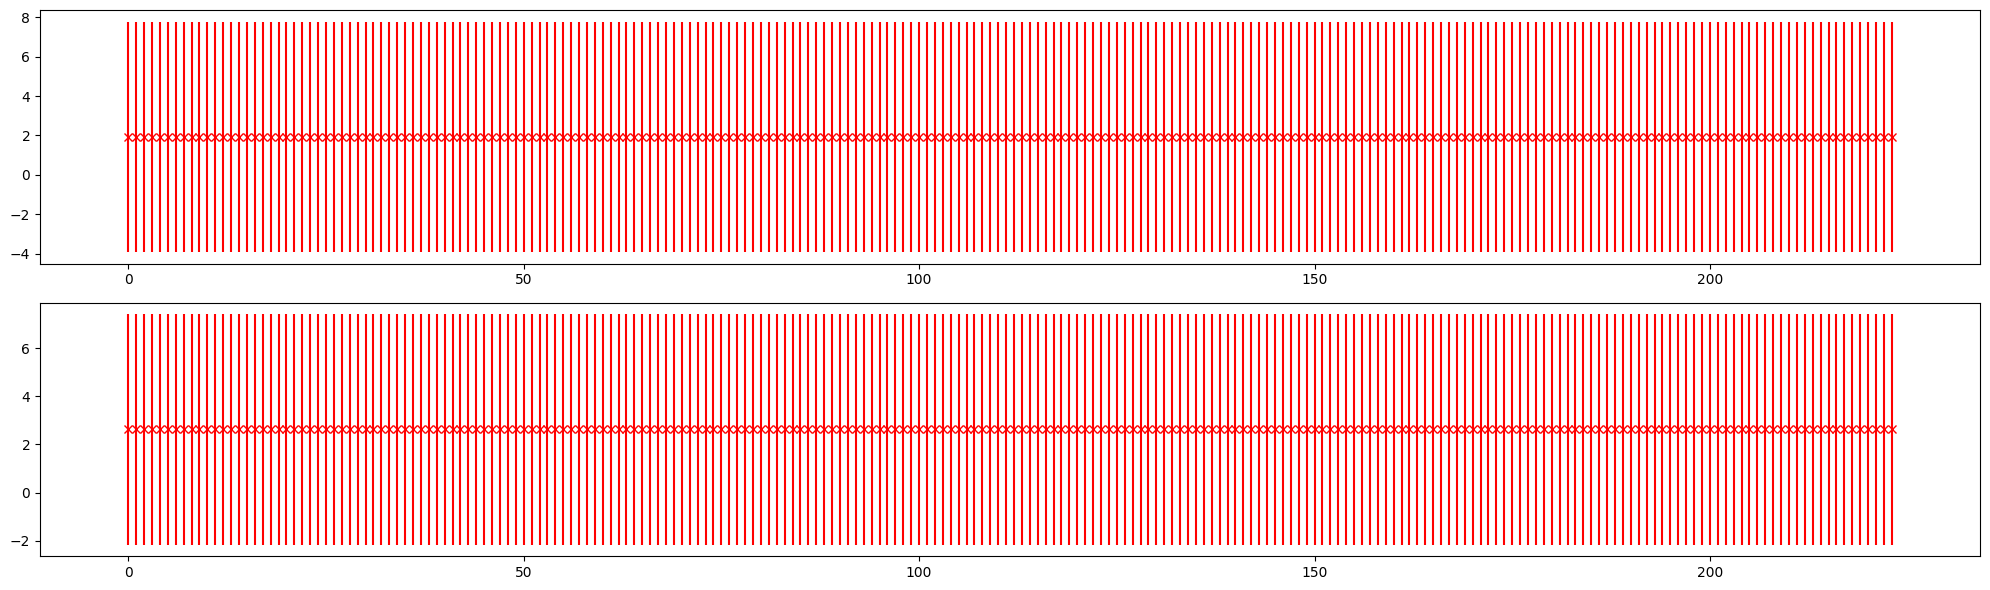

tensor(1.9284, dtype=torch.float64)
tensor(2.6289, dtype=torch.float64)



In [26]:
# Estimate twiss from amplitude (model beta functions are used to estimate invariants)
# Note, errors in invariants results in 'systematic' shift of estimated parameters

twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

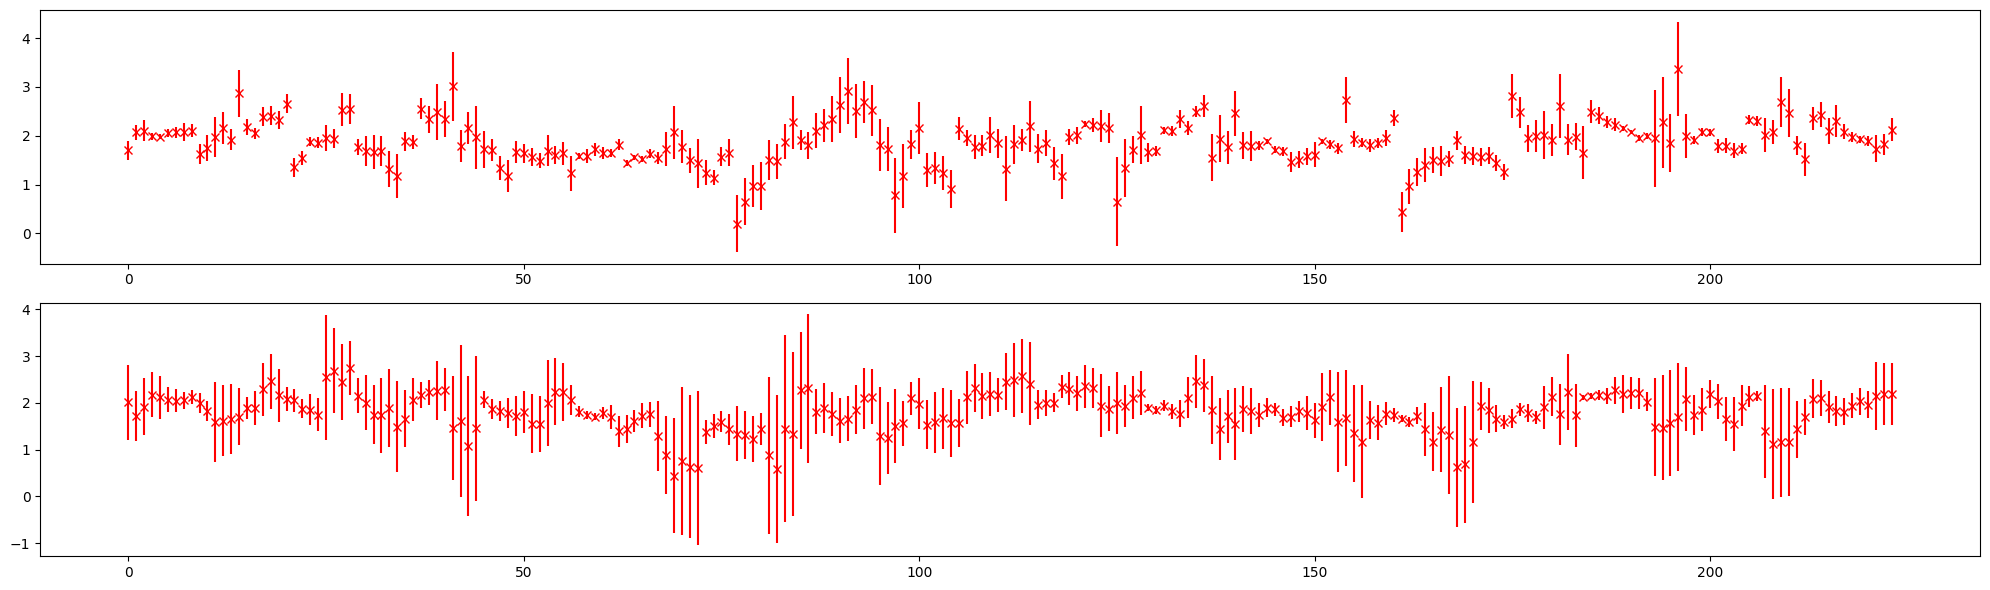

tensor(1.9210, dtype=torch.float64)
tensor(1.8486, dtype=torch.float64)



In [27]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

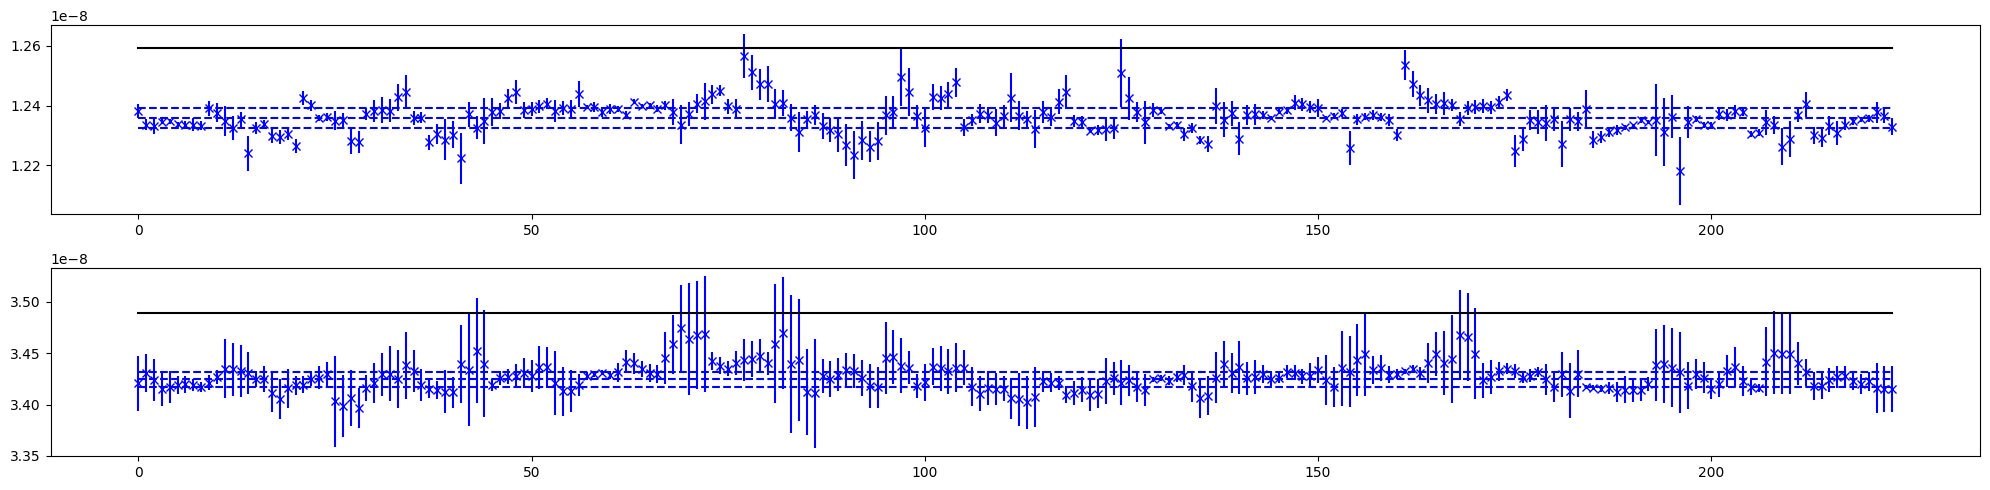

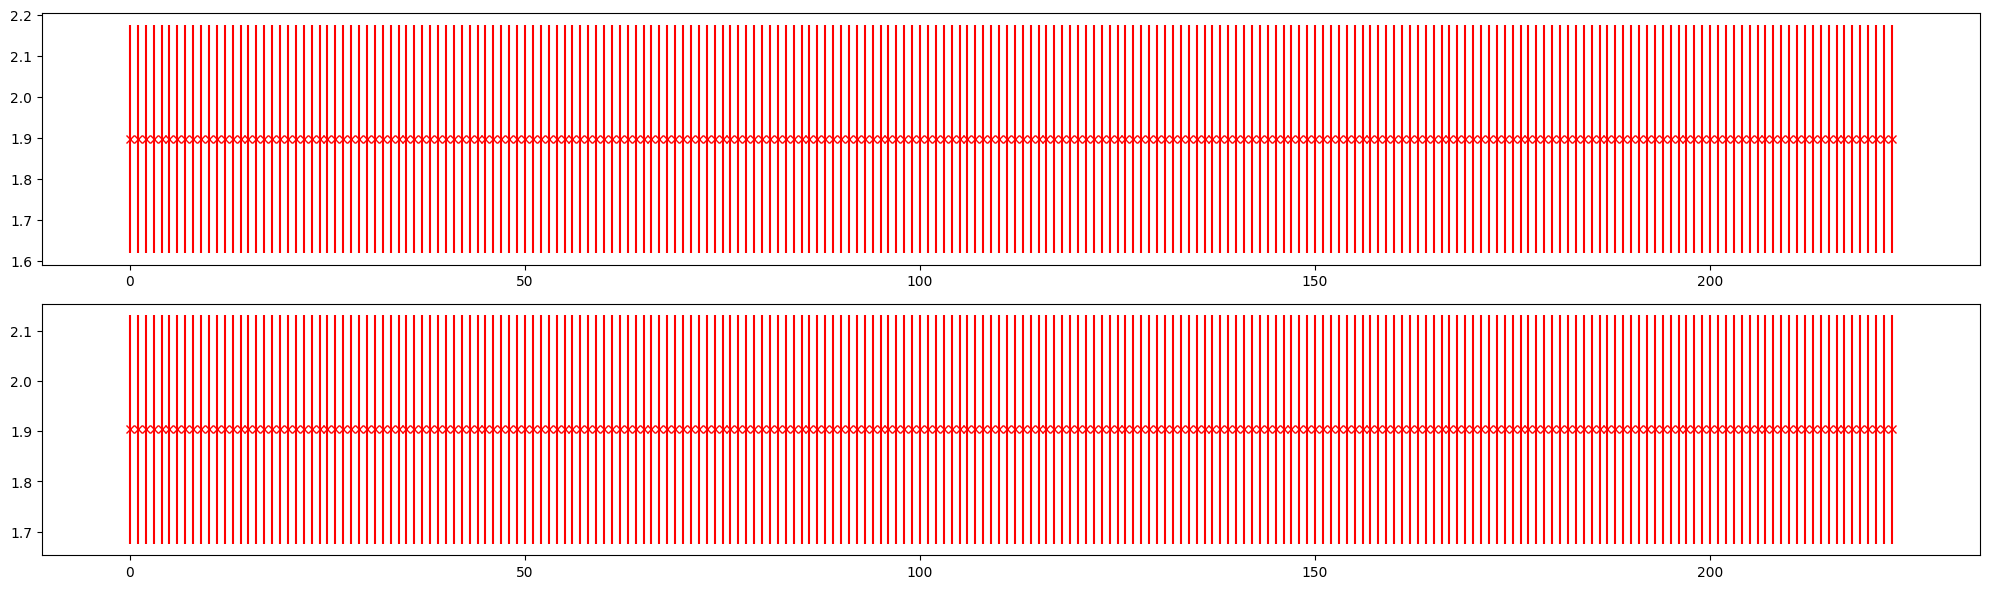

tensor(1.8974, dtype=torch.float64)
tensor(1.9035, dtype=torch.float64)



In [28]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

In [29]:
# Note, invariant values, estimated using measured amplitudes and beta function assume zero coupling
# There is a systematic shift related to error of invariant estimation

## Twiss from invariant fit

In [30]:
# Here full set of coupled twiss parameters in computed along with coupled invariants
# These invariants are required for accurate computation of normalization matrix elements from amplitudes and phases
# If bpms have calibration errors, these invariants are still provide good approximation of true invariants, if fluctuations of calibrations have zero mean
# <gxx> = <gyy> = 1 and <gxy> = <gyx>

In [31]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 9min 1s, sys: 1min 48s, total: 10min 50s
Wall time: 13min 15s


In [32]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

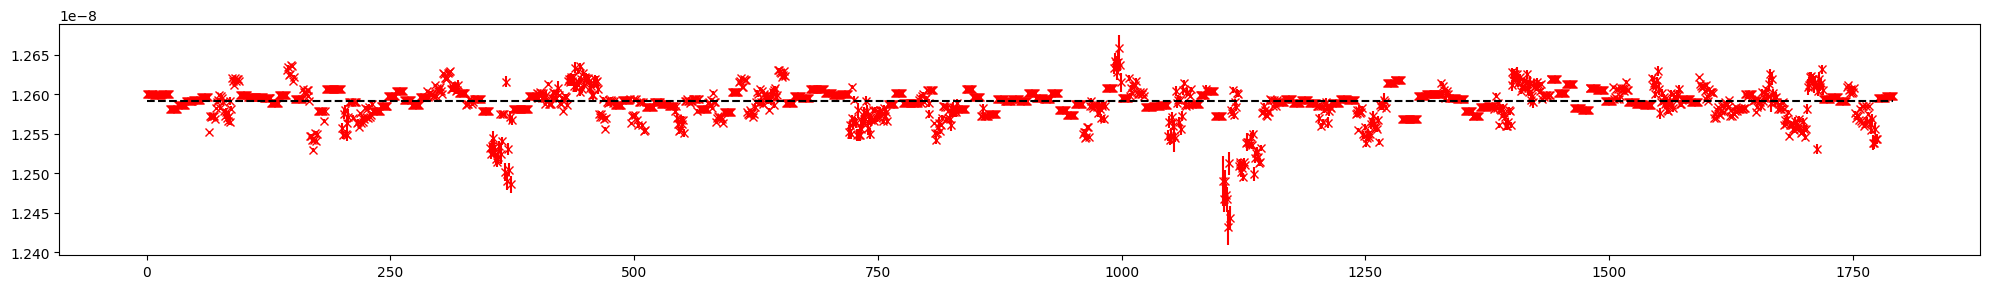

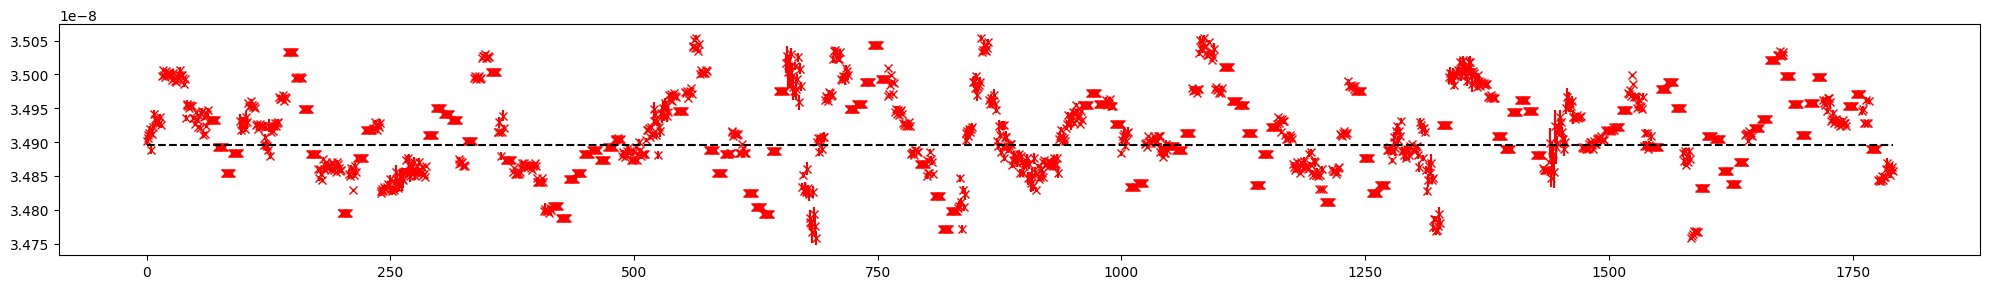

In [33]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

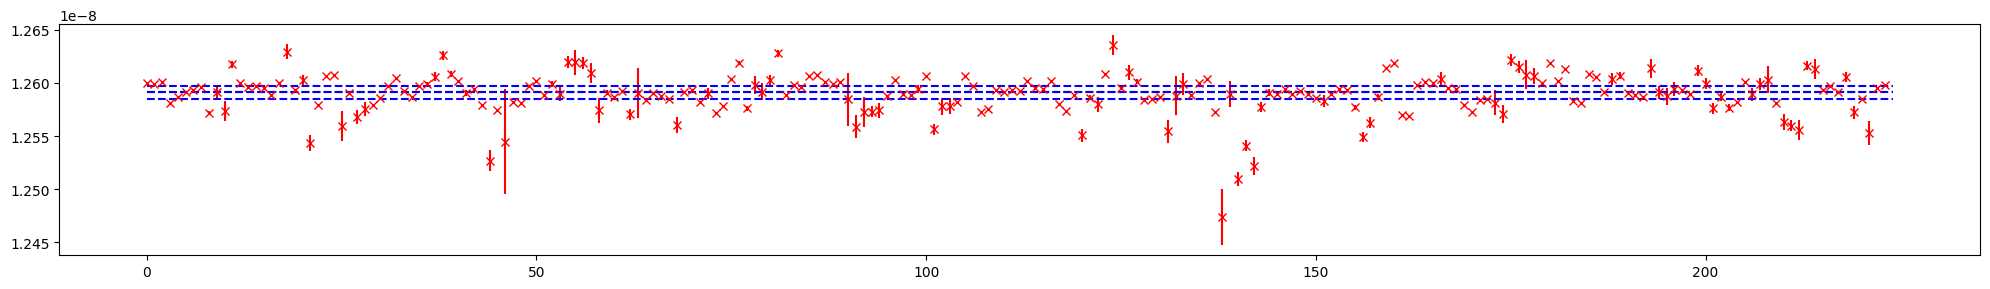

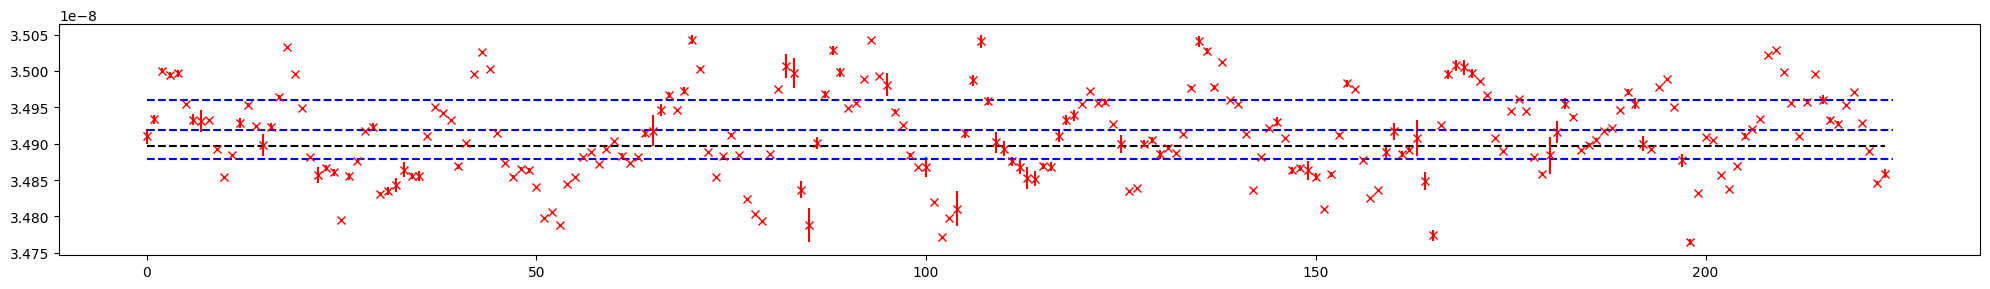

tensor(1.2592e-08, dtype=torch.float64)
tensor(1.2357e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)
tensor(1.2589e-08, dtype=torch.float64)

tensor(3.4896e-08, dtype=torch.float64)
tensor(3.4244e-08, dtype=torch.float64)
tensor(3.4919e-08, dtype=torch.float64)
tensor(3.4913e-08, dtype=torch.float64)



In [34]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

In [35]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

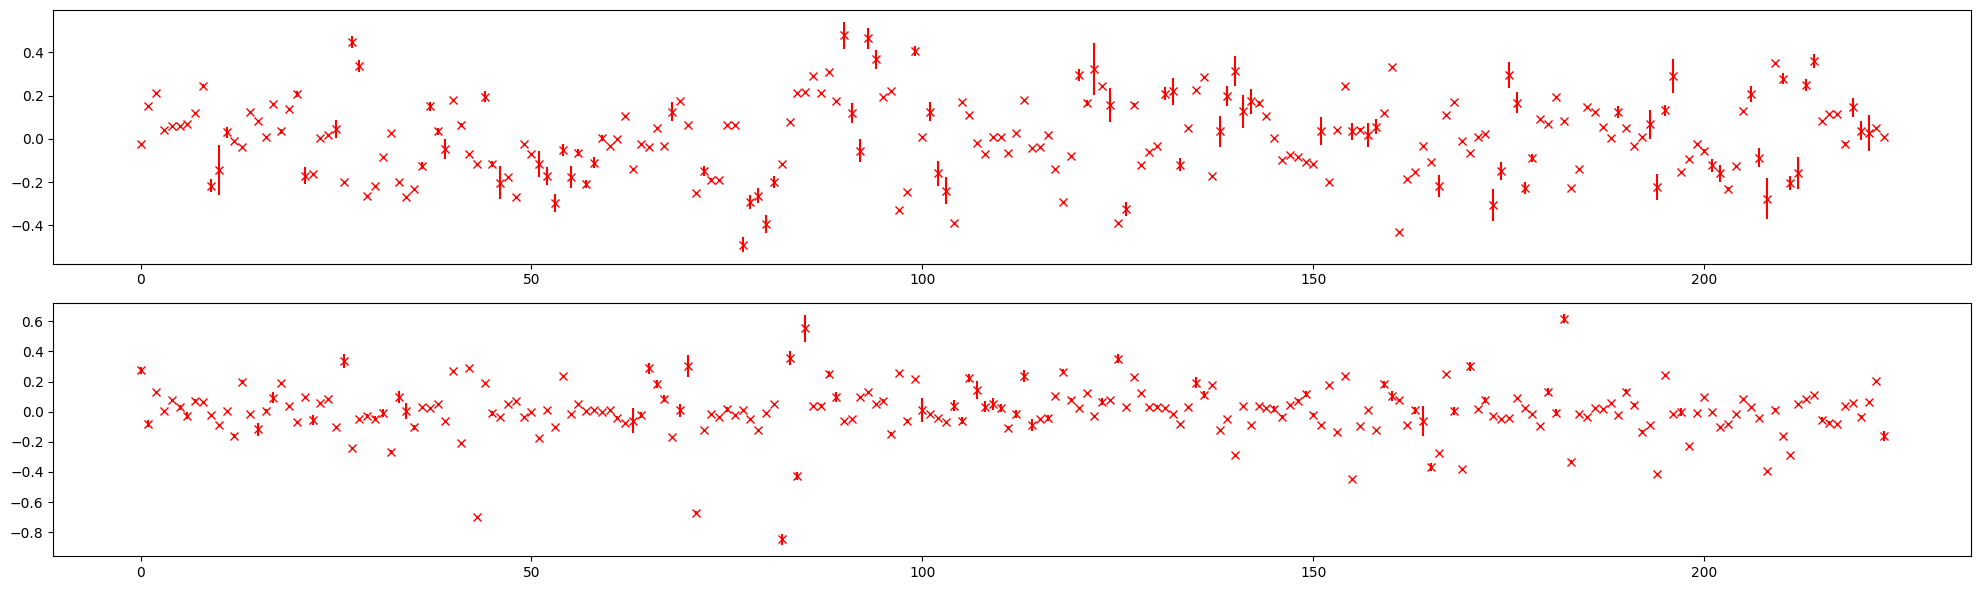

tensor(0.1819, dtype=torch.float64)
tensor(0.1722, dtype=torch.float64)



In [36]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

In [37]:
# Compare estimated normalization matrix elements

tensor(0.0027, dtype=torch.float64)

tensor(0.0016, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)

tensor(0.0025, dtype=torch.float64)

tensor(0.0011, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)



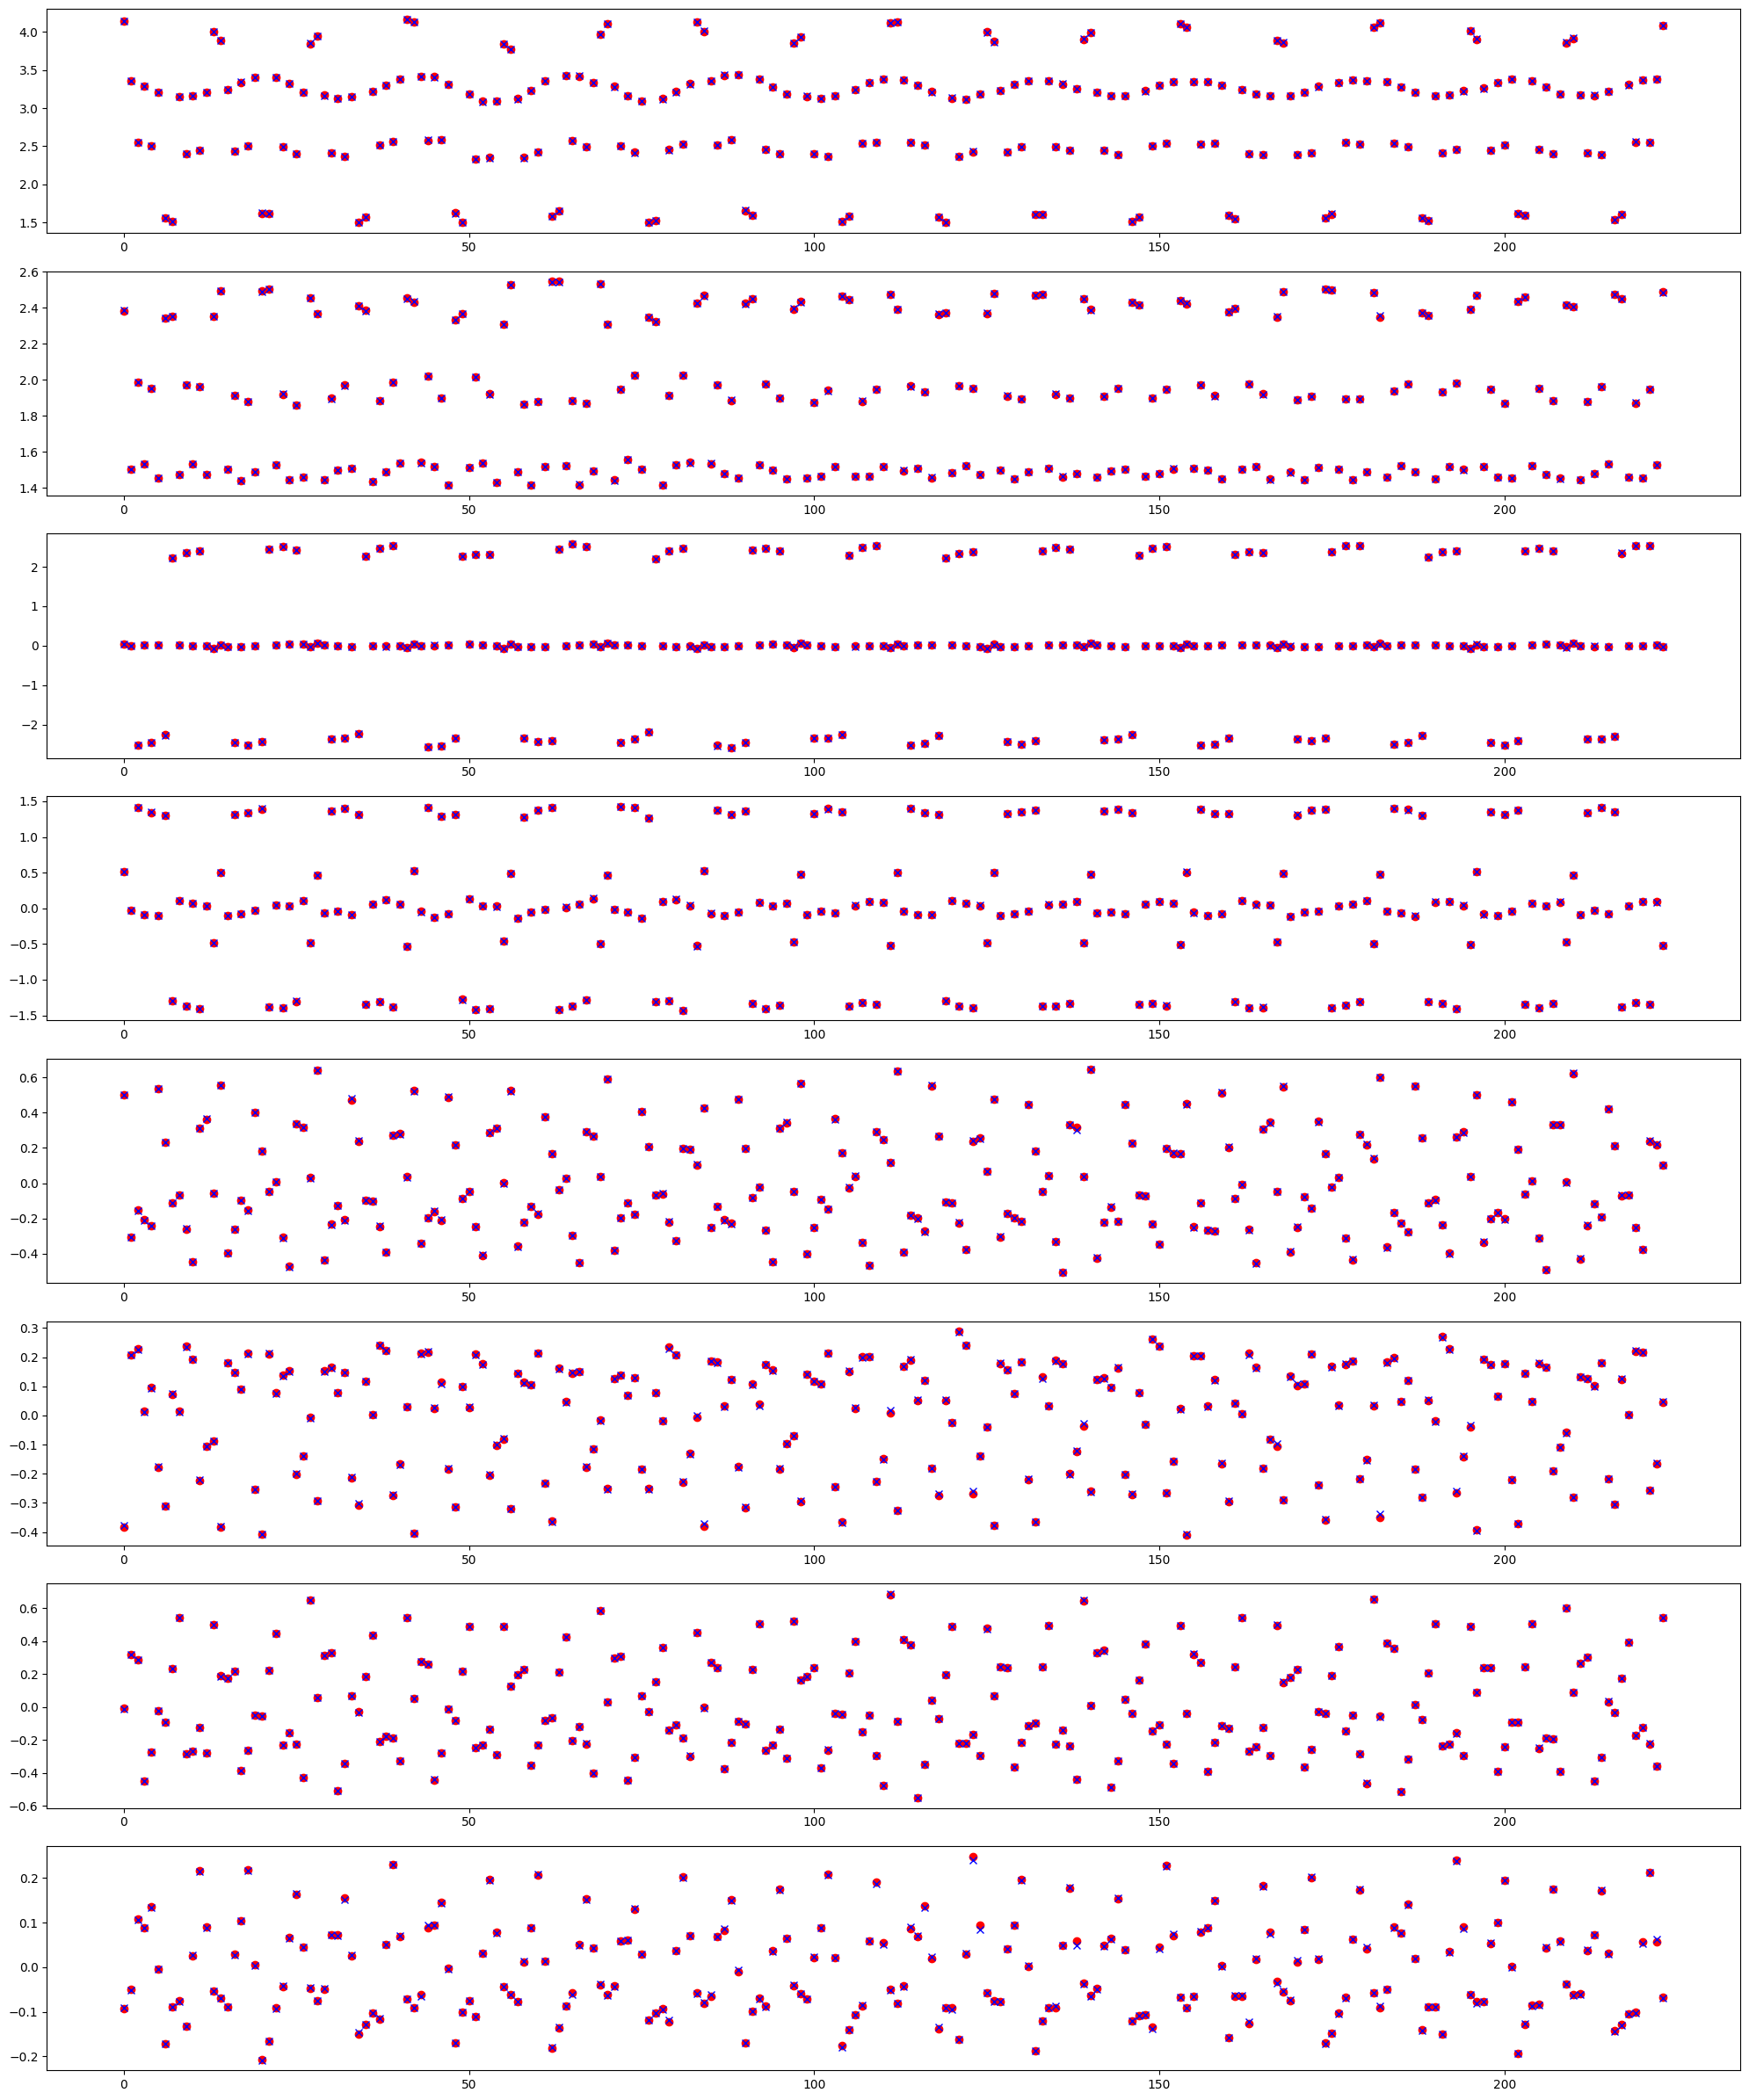

In [38]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), n21.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n21.cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), n43.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n43.cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), n41.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n41.cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [39]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [40]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

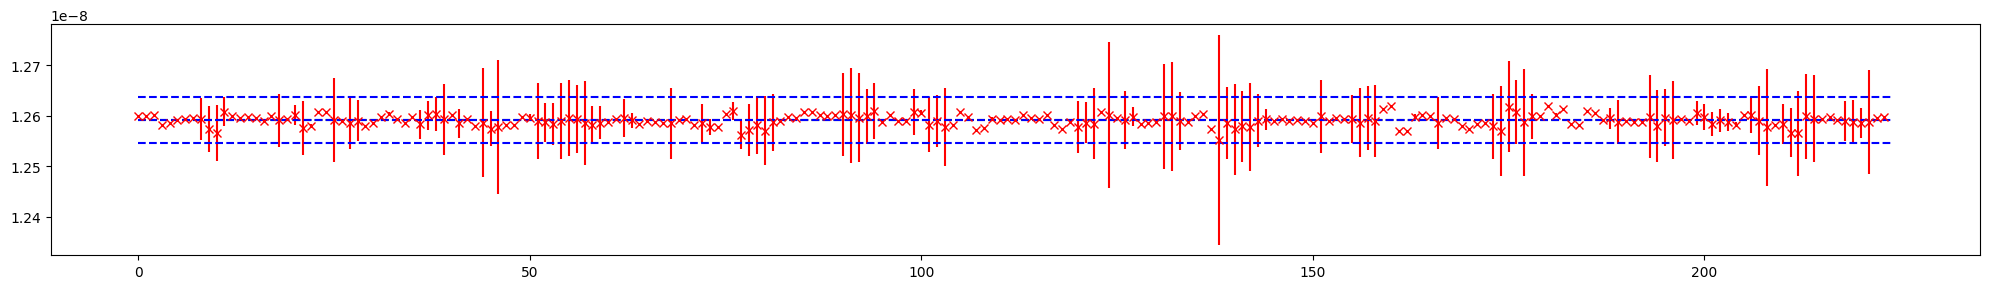

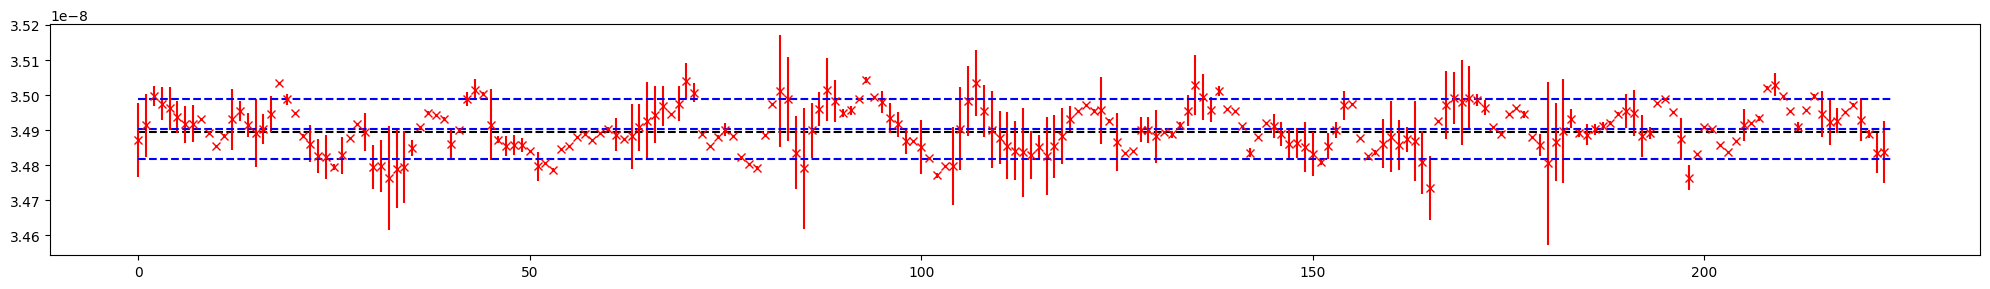

tensor(1.2592e-08, dtype=torch.float64)
tensor(1.2357e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)
tensor(1.2589e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)

tensor(3.4896e-08, dtype=torch.float64)
tensor(3.4244e-08, dtype=torch.float64)
tensor(3.4919e-08, dtype=torch.float64)
tensor(3.4913e-08, dtype=torch.float64)
tensor(3.4904e-08, dtype=torch.float64)



In [41]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

In [42]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=BAG_IX.mean(), # -- ix invariant value
                                 iy=BAG_IY.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 9min 5s, sys: 1min 26s, total: 10min 31s
Wall time: 13min


In [43]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

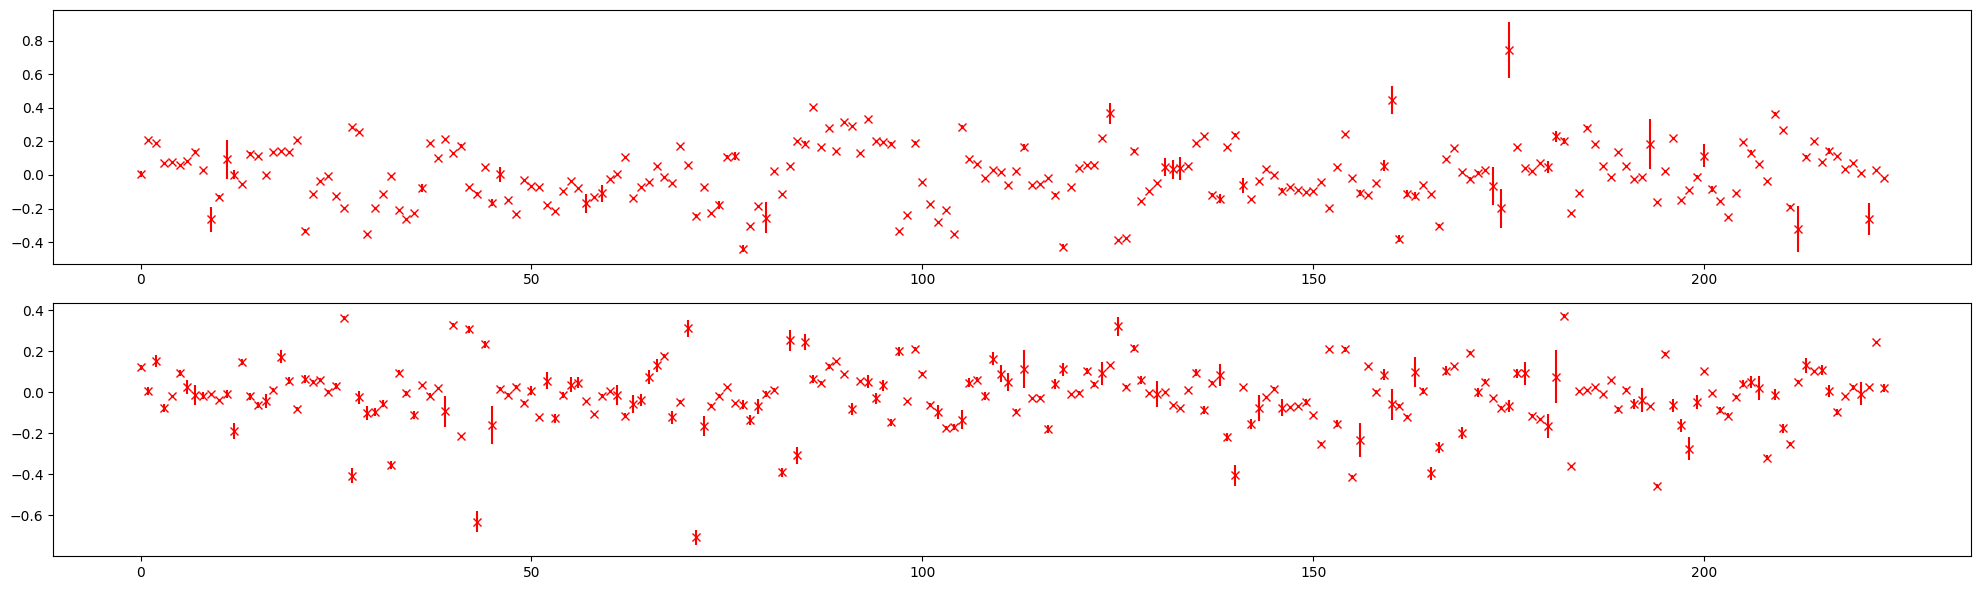

tensor(0.1760, dtype=torch.float64)
tensor(0.1539, dtype=torch.float64)



In [44]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.0025, dtype=torch.float64)

tensor(0.0014, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)

tensor(0.0021, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)

tensor(0.0026, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)



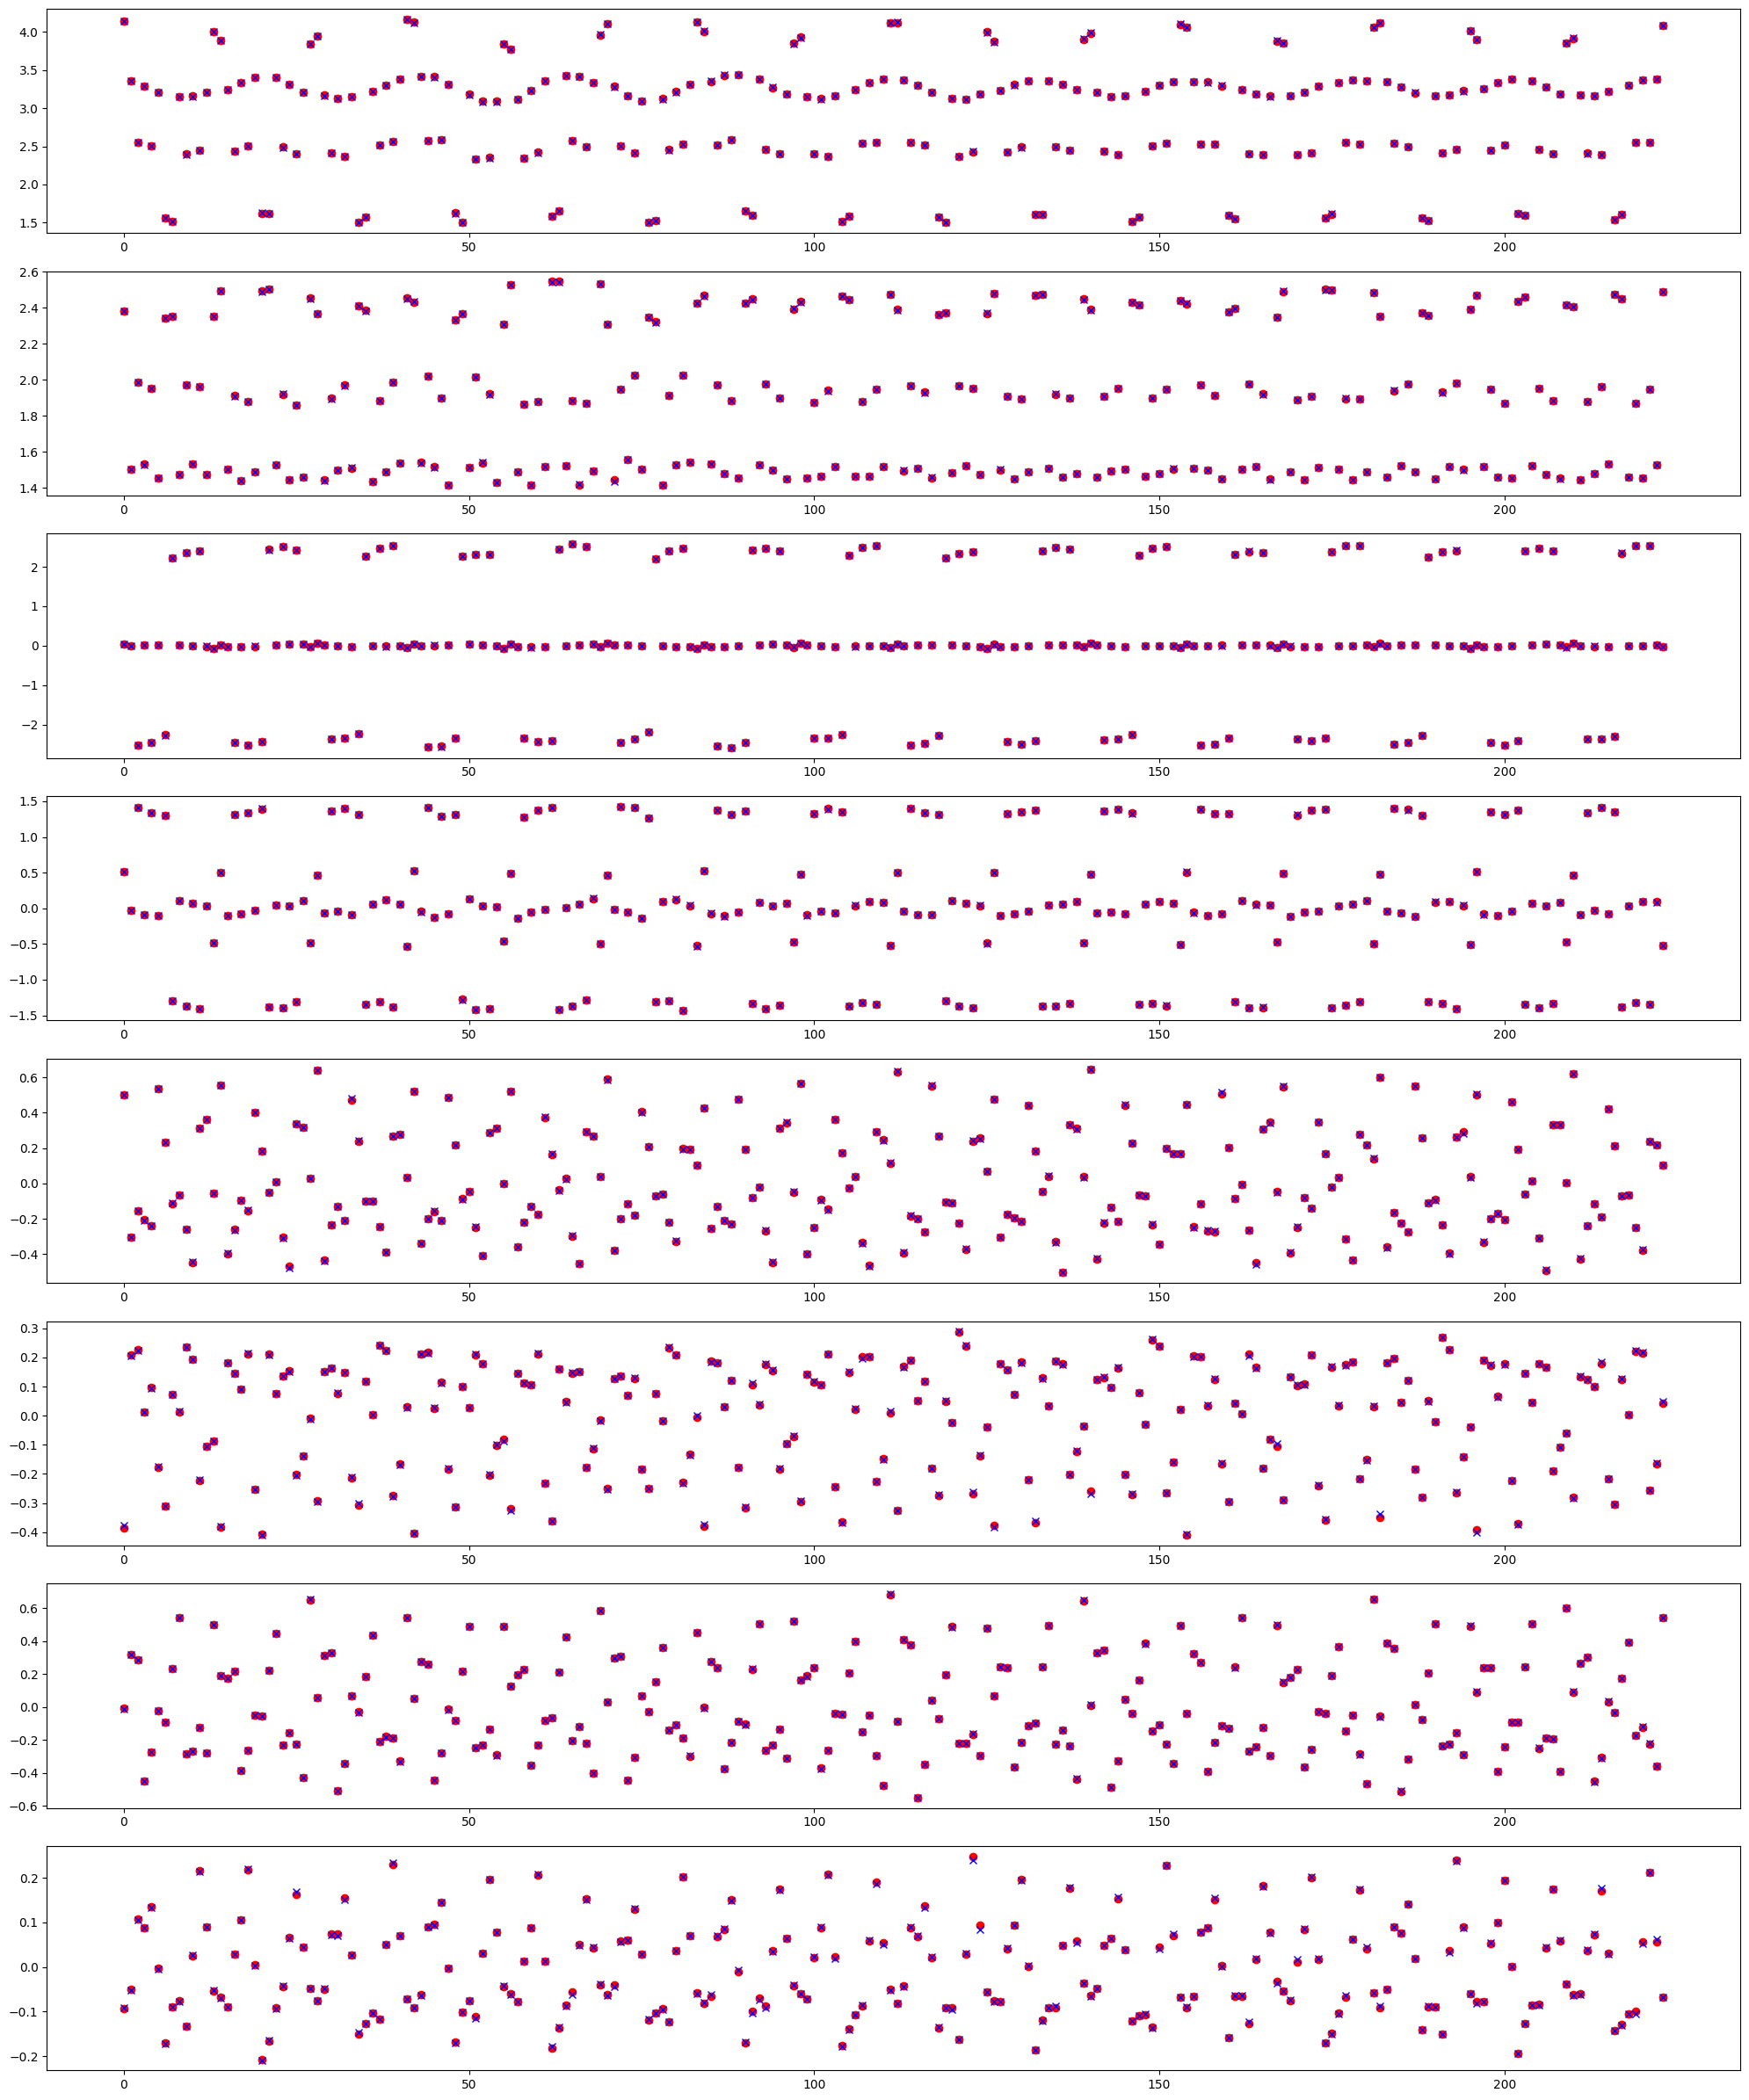

In [45]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), n21.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n21.cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), n43.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n43.cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), n41.cpu().numpy(), fmt=' ', marker='o', color='red')
ax.errorbar(range(model.monitor_count), value_n41.cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [46]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [47]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

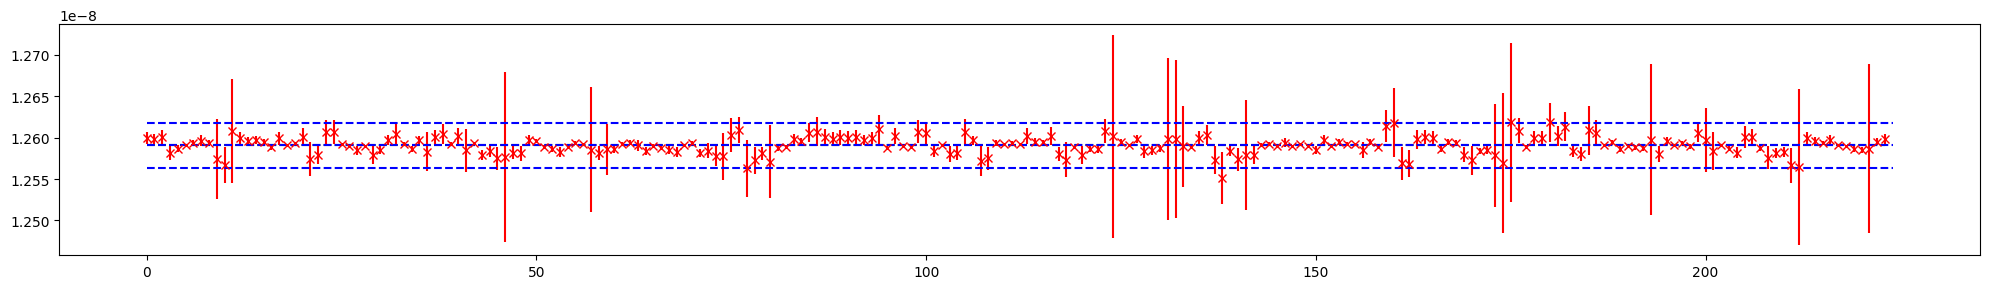

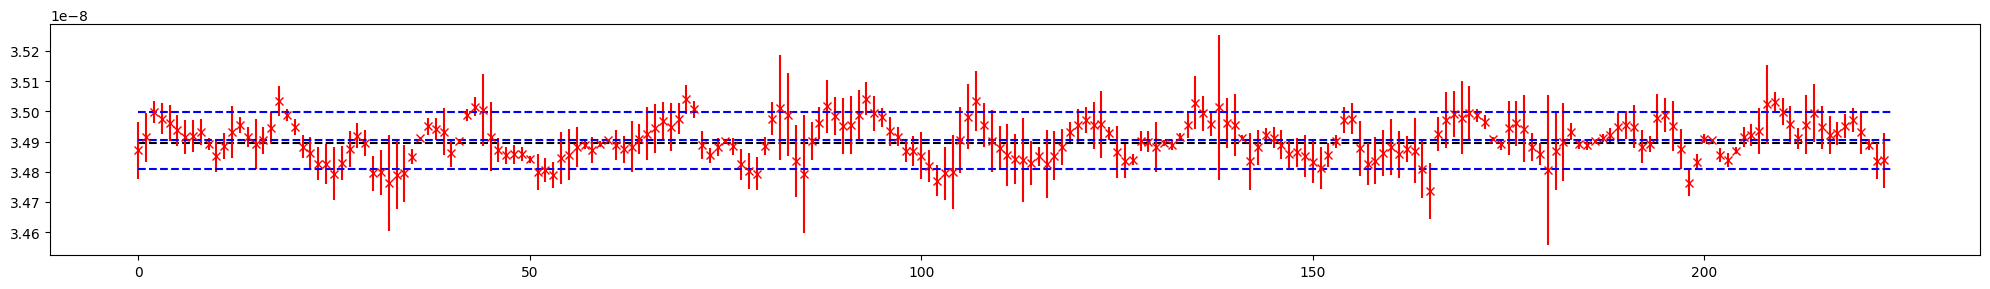

tensor(1.2592e-08, dtype=torch.float64)
tensor(1.2357e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)

tensor(3.4896e-08, dtype=torch.float64)
tensor(3.4244e-08, dtype=torch.float64)
tensor(3.4919e-08, dtype=torch.float64)
tensor(3.4904e-08, dtype=torch.float64)



In [48]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(BAG_IY.mean())
print()

In [49]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

## Normalization matrix elements from amplitude and phase

In [50]:
# Check amplitudes (using exact values for invariants and normalization matrix elements)

print(root_mean_square(axx**2 - 2*ix*n11**2))
print(root_mean_square(axy**2 - 2*iy*(n13**2 + n14**2)))
print(root_mean_square(ayx**2 - 2*ix*(n31**2 + n32**2)))
print(root_mean_square(ayy**2 - 2*iy*n33**2))

tensor(3.8423e-17, dtype=torch.float64)
tensor(3.7647e-17, dtype=torch.float64)
tensor(1.5514e-17, dtype=torch.float64)
tensor(1.4986e-17, dtype=torch.float64)


In [51]:
# Check phases (using exact values for invariants and normalization matrix elements)

print(root_mean_square(fxy - torch.atan2((fyy.sin() * n13 + fyy.cos() * n14), (fyy.cos() * n13 - fyy.sin() * n14))))
print(root_mean_square(fyx - torch.atan2((fxx.sin() * n31 + fxx.cos() * n32), (fxx.cos() * n31 - fxx.sin() * n32))))

tensor(2.7895e-10, dtype=torch.float64)
tensor(7.3757e-10, dtype=torch.float64)


In [52]:
# Check normalization matrix elements (using exact values for invariants and normalization matrix elements)

print(root_mean_square(n11**2 - axx**2/(2*ix)))
print(root_mean_square(n33**2 - ayy**2/(2*iy)))
print(root_mean_square((n13**2 + n14**2) - axy**2/(2*iy)))
print(root_mean_square((n31**2 + n32**2) - ayx**2/(2*ix)))
print(root_mean_square(n13 - axy/ayy*(fxy - fyy).cos()*n33))
print(root_mean_square(n14 - axy/ayy*(fxy - fyy).sin()*n33))
print(root_mean_square(n31 - ayx/axx*(fyx - fxx).cos()*n11))
print(root_mean_square(n32 - ayx/axx*(fyx - fxx).sin()*n11))

tensor(1.5257e-09, dtype=torch.float64)
tensor(2.1473e-10, dtype=torch.float64)
tensor(5.3942e-10, dtype=torch.float64)
tensor(6.1603e-10, dtype=torch.float64)
tensor(4.2980e-10, dtype=torch.float64)
tensor(4.2473e-10, dtype=torch.float64)
tensor(7.7420e-10, dtype=torch.float64)
tensor(7.4794e-10, dtype=torch.float64)


In [53]:
# To compute  estimations of n11 and n33 from experimental data, approximation of invariants (ix and iy) are required
# As it can be see from the previous subsection, coupled invariants can be accuratly approximated

ix_fit = BAG_IX.mean()
iy_fit = BAG_IY.mean()

print(ix.mean())
print(ix_fit)
print()

print(iy.mean())
print(iy_fit.mean())
print()

tensor(1.2592e-08, dtype=torch.float64)
tensor(1.2591e-08, dtype=torch.float64)

tensor(3.4896e-08, dtype=torch.float64)
tensor(3.4904e-08, dtype=torch.float64)



tensor(0.0025, dtype=torch.float64)
tensor(0.0001, dtype=torch.float64)

tensor(0.0014, dtype=torch.float64)
tensor(0.0002, dtype=torch.float64)

tensor(0.0022, dtype=torch.float64)
tensor(3.2523e-05, dtype=torch.float64)

tensor(0.0015, dtype=torch.float64)
tensor(3.2738e-05, dtype=torch.float64)

tensor(0.0026, dtype=torch.float64)
tensor(6.9839e-06, dtype=torch.float64)

tensor(0.0010, dtype=torch.float64)
tensor(6.9693e-06, dtype=torch.float64)



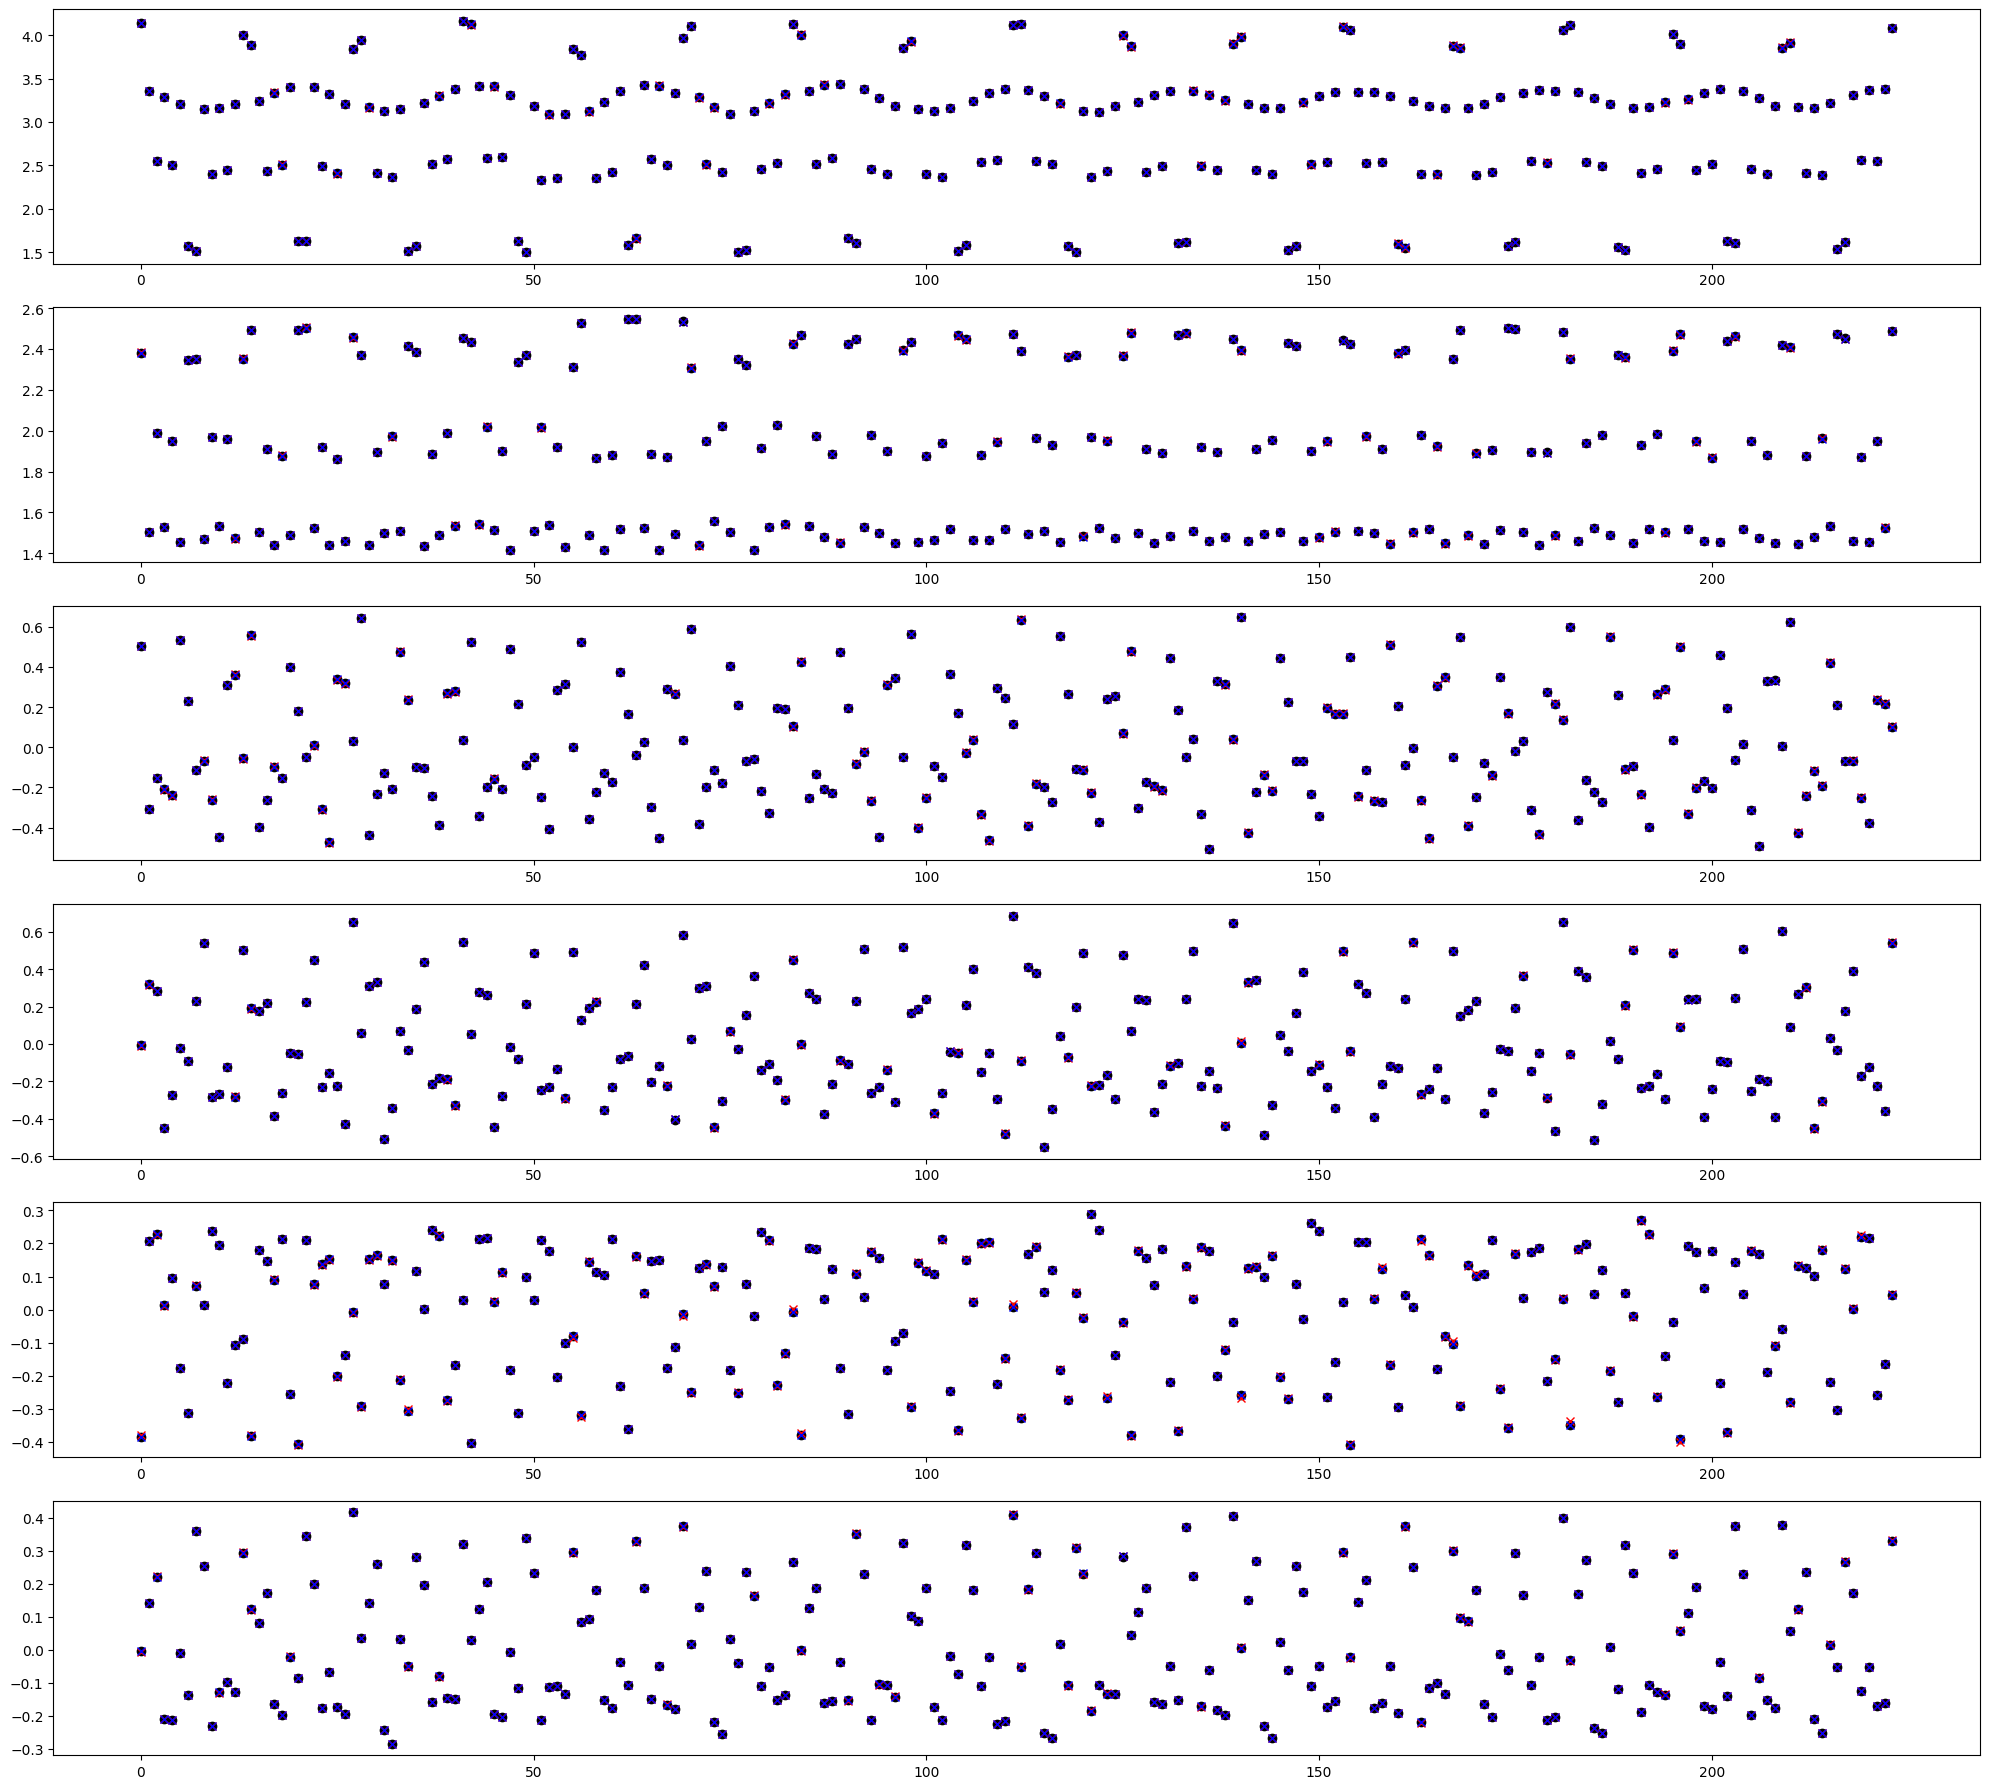

In [54]:
# Compute estimated normalization matrix element and with compare exact and fitted values

n11_estimate = axx/(2*ix_fit).sqrt()
n33_estimate = ayy/(2*iy_fit).sqrt()
n13_estimate = axy/ayy*(fxy - fyy).cos()*n33_estimate
n14_estimate = axy/ayy*(fxy - fyy).sin()*n33_estimate
n31_estimate = ayx/axx*(fyx - fxx).cos()*n11_estimate
n32_estimate = ayx/axx*(fyx - fxx).sin()*n11_estimate

plt.figure(figsize=(20, 3*6))

ax = plt.subplot(611)
ax.errorbar(range(model.monitor_count), n11.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n11_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11 - n11_estimate))
print()

ax = plt.subplot(612)
ax.errorbar(range(model.monitor_count), n33.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n33_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33 - n33_estimate))
print()

ax = plt.subplot(613)
ax.errorbar(range(model.monitor_count), n13.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n13_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13 - n13_estimate))
print()

ax = plt.subplot(614)
ax.errorbar(range(model.monitor_count), n14.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n14_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14 - n14_estimate))
print()

ax = plt.subplot(615)
ax.errorbar(range(model.monitor_count), n31.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n31_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31 - n31_estimate))
print()

ax = plt.subplot(616)
ax.errorbar(range(model.monitor_count), n32.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), value_n32.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), n32_estimate.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n32 - value_n32))
print(root_mean_square(n32 - n32_estimate))
print()

plt.tight_layout()
plt.show()

# As it can be seen from rms values, accuracy in significantly improved

In [55]:
# BPM calibration errors (gxx, gxy, gyx, gyy) effect observed parameters of harmonics (amplitudes and phases)

# qx_bpm = gxx qx + gxy qy
# qy_bpm = gyy qy + gyx qx

# Here, amplitudes and phases are used directly for estimation of normalization matrix elements
# Thus, estimated parameters are expected to be closer to BPM frame parameters
# This is in contrust to beta function estimation from phase or full coupled twiss estimation methods
# BPM frame parameters are connected with beam frame twiss via the following expressions

# n[1,1]->(gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2]
# n[3,3]->(gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2]
# n[1,3]->(gxx gyx (n[1,3]^2+n[1,4]^2)+(gxy gyx+gxx gyy) n[1,3] n[3,3]+gxy gyy n[3,3]^2)/((gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])
# n[1,4]->((-gxy gyx+gxx gyy) n[1,4] n[3,3])/((gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])
# n[3,1]->((gxx n[1,1]+gxy n[3,1]) (gyx n[1,1]+gyy n[3,1])+gxy gyy n[3,2]^2)/((gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])
# n[3,2]->((-gxy gyx+gxx gyy) n[1,1] n[3,2])/((gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])

# Also, for other elements, the expressions are 

# n[1,2]->0
# n[2,1]->(gxy gyy (n[2,1] n[3,1]+n[2,2] n[3,2])+gxx n[1,1] (gyy n[2,1]-gyx n[4,1])-gxy gyx (n[3,1] n[4,1]+n[3,2] n[4,2]))/((-gxy gyx+gxx gyy) (gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])
# n[2,2]->(gxx gyy n[1,1] n[2,2]+gxy gyy n[2,2] n[3,1]-gxy gyy n[2,1] n[3,2]+gxy gyx n[3,2] n[4,1]-gyx (gxx n[1,1]+gxy n[3,1]) n[4,2])/((-gxy gyx+gxx gyy) (gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])
# n[2,3]->(-gyy^2 n[2,3] n[3,3]-gyx gyy (n[1,3] n[2,3]+n[1,4] n[2,4]-n[3,3] n[4,3])+gyx^2 (n[1,3] n[4,3]+n[1,4] n[4,4]))/((gxy gyx-gxx gyy) (gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])
# n[2,4]->(-gyy^2 n[2,4] n[3,3]+gyx^2 (-n[1,4] n[4,3]+n[1,3] n[4,4])+gyx gyy (n[1,4] n[2,3]-n[1,3] n[2,4]+n[3,3] n[4,4]))/((gxy gyx-gxx gyy) (gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])
# n[3,4]->0
# n[4,1]->(-gxy^2 (n[2,1] n[3,1]+n[2,2] n[3,2])+gxx^2 n[1,1] n[4,1]+gxx gxy (-n[1,1] n[2,1]+n[3,1] n[4,1]+n[3,2] n[4,2]))/((-gxy gyx+gxx gyy) (gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])
# n[4,2]->(-gxy (gxx n[1,1] n[2,2]+gxy n[2,2] n[3,1]-gxy n[2,1] n[3,2]+gxx n[3,2] n[4,1])+gxx (gxx n[1,1]+gxy n[3,1]) n[4,2])/((-gxy gyx+gxx gyy) (gxx n[1,1]+gxy n[3,1]) Sqrt[1+(gxy^2 n[3,2]^2)/(gxx n[1,1]+gxy n[3,1])^2])
# n[4,3]->(gxy (gyx n[1,3] n[2,3]+gyx n[1,4] n[2,4]+gyy n[2,3] n[3,3])-gxx ((gyx n[1,3]+gyy n[3,3]) n[4,3]+gyx n[1,4] n[4,4]))/((gxy gyx-gxx gyy) (gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])
# n[4,4]->(gxy (-gyx n[1,4] n[2,3]+gyx n[1,3] n[2,4]+gyy n[2,4] n[3,3])+gxx gyx n[1,4] n[4,3]-gxx (gyx n[1,3]+gyy n[3,3]) n[4,4])/((gxy gyx-gxx gyy) (gyx n[1,3]+gyy n[3,3]) Sqrt[1+(gyx^2 n[1,4]^2)/(gyx n[1,3]+gyy n[3,3])^2])} 


# First order expressions with respect to calibration parameters
# Note, here gxx is replaced by 1 + gxx and expansion is with respect to deviation, similar for gyy

# n11->n11+gxx n11+gxy n31
# n12->0
# n13->n13+(gyx n14^2+gxx n13 n33+gxy n33^2)/n33
# n14->n14+(n14 (-gyx n13+gxx n33))/n33
# n21->n21+(-gxx n11 n21+gxy n22 n32-gyx n11 n41)/n11
# n22->n22+(-gxx n11 n22-gxy n21 n32-gyx n11 n42)/n11
# n23->n23+(gyx n14 n24-gxx n23 n33-gyx n33 n43)/n33
# n24->n24+(-gyx n14 n23-gxx n24 n33-gyx n33 n44)/n33
# n31->n31+(gyx n11^2+gyy n11 n31+gxy n32^2)/n11
# n32->n32+((gyy n11-gxy n31) n32)/n11
# n33->gyx n13+n33+gyy n33
# n34->0
# n41->n41+(-gxy n11 n21-gyy n11 n41+gxy n32 n42)/n11
# n42->n42+(-gxy n11 n22-gxy n32 n41-gyy n11 n42)/n11
# n43->n43+(-gxy n23 n33-gyy n33 n43+gyx n14 n44)/n33
# n44->n44+(-gxy n24 n33-gyx n14 n43-gyy n33 n44)/n33

# This implies, that estimated BPM frame elements n11, n33, n13, n14, n31 and n32 are approximatly related with corresponding beam frame elements via BPM scales

# n11->n11+gxx n11+gxy n31->n11+gxx n11 (n11 >> n31 and gxy << 1)
# n33->gyx n13+n33+gyy n33->n33+gyy n33 (n33 >> n13 and gyx << 1)
# n13->n13+(gyx n14^2+gxx n13 n33+gxy n33^2)/n33->n13+gxx n13 (n33 >> n14 and gyx << 1, not as accurate as other elements due to gxy n33 term)
# n14->n14+(n14 (-gyx n13+gxx n33))/n33->n14+gxx n14 (n33 >> n13 and gyx << 1)
# n31->n31+(gyx n11^2+gyy n11 n31+gxy n32^2)/n11->n31+gyy n31 (n11 >> n32 and gxy << 1, not as accurate as other elements due to gyx n11 term)
# n32->n32+((gyy n11-gxy n31) n32)/n11->n32+gyy n32 (n11 >> n31 and gxy << 1)

# Given calibration scales gxx and gyy, BPM frame elements n11, n33, n14, n32 can be transformed to beam frame
# Elements n13 and n31 (or coupled beta functions) also can be transformed, but accuracy is not as good in this case

# Calibration scales (gxx, gyy) can be estimated from ratio of beta functions computed from amplitude and from phase
# Assuming <gxx> = <gyy> = 1 and <gxy> = <gyx> = 0

# Without coupling expressions for matrix elements reduce to

# n11->Sqrt[bx] gxx 
# n12->0
# n13->Sqrt[by] gxy
# n14->0
# n21->(ax gyy)/(Sqrt[bx] (gxy gyx-gxx gyy))
# n22->gyy/(Sqrt[bx] (-gxy gyx+gxx gyy))
# n23->(ay gyx)/(Sqrt[by] (-gxy gyx+gxx gyy))
# n24->gyx/(Sqrt[by] (gxy gyx-gxx gyy))
# n31->Sqrt[bx] gyx
# n32->0
# n33->Sqrt[by] gyy
# n34->0
# n41->(ax gxy)/(Sqrt[bx] (-gxy gyx+gxx gyy))
# n42->gxy/(Sqrt[bx] (gxy gyx-gxx gyy))
# n43->(ay gxx)/(Sqrt[by] (gxy gyx-gxx gyy))
# n44->gxx/(Sqrt[by] (-gxy gyx+gxx gyy))
# n31->Sqrt[bx] gyx -> gyx
# n33->Sqrt[by] gyy -> gyy

# This implies, the signs of gyx and gyy match the signs of n13 and n31

# With calibration errors phases fxx, fxy, fyx and fyy do depend on calibration errors in coupled case

# fxy_bpm - fyy_bpm = fxy - fyy + O(gxy) + O(gyx)
# fyx_bpm - fxx_bpm = fxy - fyy + O(gxy) + O(gyx)

# Amplitudes can be transformed using gxx and gyy

# axx_bpm = gxx axx + O(gxy) + O(gyx)
# axy_bpm = gxx axy + O(gxy) + O(gyx)
# axy_bpm = gyy ayx + O(gxy) + O(gyx)
# ayy_bpm = gyy ayy + O(gxy) + O(gyx)